Understanding Customer Dissatisfaction using Amazon Reviews

In [ ]:
#Loading Libraries
import pandas as pd                     
import numpy as np                      
import re                               
import matplotlib.pyplot as plt         
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer
import nltk

# Download WordNet data needed for lemmatization
nltk.download("wordnet")
nltk.download("omw-1.4")

# Create a lemmatizer object
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
#Loading the dataset
df_raw = pd.read_csv(r"C:\\Users\\ADMIN\\Documents\\Organisational Analytics\\Amazon_Reviews.csv\\Amazon_Reviews.csv")

#Clean the dataset
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
)

# Print column names to inspect them
print(df_raw.columns)

Index(['reviewer_name', 'profile_link', 'country', 'review_count',
       'review_date', 'rating', 'review_title', 'review_text',
       'date_of_experience'],
      dtype='object')


In [7]:
#Exploratory Data Analysis
print(df_raw.info())
print(df_raw.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   reviewer_name       21214 non-null  object
 1   profile_link        21163 non-null  object
 2   country             21054 non-null  object
 3   review_count        21055 non-null  object
 4   review_date         21055 non-null  object
 5   rating              21055 non-null  object
 6   review_title        21055 non-null  object
 7   review_text         21055 non-null  object
 8   date_of_experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB
None
      reviewer_name                     profile_link country review_count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         G

In [ ]:
# Identifying Key Columns
df = pd.DataFrame({
    "review_id": range(1, len(df_raw) + 1),                         
    "rating": pd.to_numeric(                                      
        df_raw["rating"].astype(str).str.extract(r"(\d+\.?\d*)")[0],   
        errors="coerce"                                            
    ),
    "text": df_raw["review_text"].astype(str)              
})

# Remove rows with missing data
df = df[
    df["rating"].notna() &
    df["text"].notna() &
    (df["text"].str.strip() != "")
]

 
print(df["rating"].describe())
print(df["rating"].value_counts().sort_index())
print(df["text"].head(2))


count    21055.000000
mean         2.186654
std          1.676769
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64
rating
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64
0    I registered on the website, tried to order a ...
1    Had multiple orders one turned up and driver h...
Name: text, dtype: object


->The median rating is 1, indicating a strong skew toward negative reviews.

->The mean rating (2.187) suggests overall dissatisfaction in the dataset.

->This confirms the dataset is suitable for analyzing drivers of 1-star reviews.

->A large number of 1-star reviews (13,123) gives strong statistical power.

->Presence of 4–5 star reviews (5,820) allows meaningful comparison.


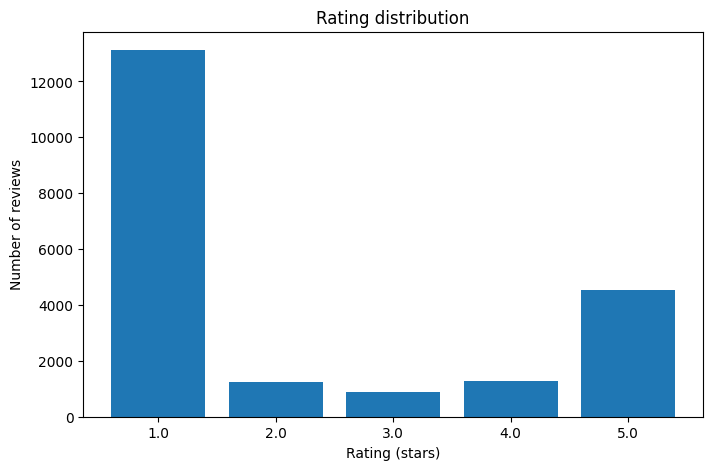

In [ ]:
#VISUALIZATION 1: Rating distribution
rating_counts = df["rating"].value_counts().sort_index()

# Create a bar chart of rating counts
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Rating distribution")
plt.xlabel("Rating (stars)")
plt.ylabel("Number of reviews")
plt.show()


There are a lot of unhappy customers, as seen by the rating distribution's strong skew toward 1-star ratings.  Positive reviews do exist, but they are much fewer than negative ones, indicating that the consumer experience is inconsistent.  This disparity emphasizes how crucial it is to examine 1-star evaluations in order to pinpoint the main reasons for discontent and operational failure.


In [11]:
#Create Rating Groups: "1-star" & "4-5 star" rating 
df["group"] = np.where(
    df["rating"] == 1,
    "1-star",
    np.where(df["rating"].isin([4, 5]), "4-5 star", None)
)

# Remove rows not in either group
df = df[df["group"].notna()].copy()

# Print counts per group
print(df["group"].value_counts())

group
1-star      13123
4-5 star     5820
Name: count, dtype: int64


There are 13123 ratings in the 1-star group and 5820 in the 4-5 star group.

<Figure size 800x500 with 0 Axes>

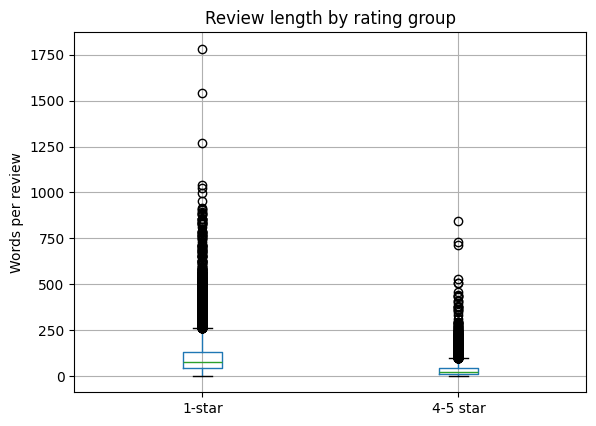

In [ ]:
# VISUALIZATION 2: Review length by group
df["review_len_words"] = df["text"].str.count(r"\S+")

# Boxplot
plt.figure(figsize=(8, 5))
df.boxplot(column="review_len_words", by="group")
plt.title("Review length by rating group")
plt.suptitle("")   
plt.xlabel("")
plt.ylabel("Words per review")
plt.show()

In terms of both median length and variability, the boxplot demonstrates that 1-star ratings are significantly longer than 4–5 star evaluations. Dissatisfied customers tend to provide detailed explanations of their experiences, often describing multiple problems, which results in longer and more diverse review texts. Positive evaluations, on the other hand, are typically shorter and more precise. The use of 1-star reviews for in-depth text analysis and subject modeling is supported by this pattern.


In [13]:
# Keep only rows where group is 1-star
df_1star = df[df["group"] == "1-star"].copy()


In [ ]:
# Create a stopword set
stop_words = set(ENGLISH_STOP_WORDS)

# Define a function to clean and lemmatize text
def clean_text(text):
    text = text.lower()                                
    text = re.sub(r"[^\w\s]", " ", text)              
    text = re.sub(r"\d+", " ", text)               
    text = re.sub(r"\s+", " ", text).strip()          
    words = text.split()                              
    words = [w for w in words if w not in stop_words] 
    words = [lemmatizer.lemmatize(w) for w in words]  
    return " ".join(words)                            

# Apply text cleaning to 1-star reviews
df_1star["clean_text"] = df_1star["text"].apply(clean_text)


In [15]:
#Create Document-Term Matrix for 1-star reviews
vectorizer_1star = CountVectorizer(min_df=1, token_pattern=r"\b[a-zA-Z]{3,}\b")
dtm_1star = vectorizer_1star.fit_transform(df_1star["clean_text"])
print("DTM shape:", dtm_1star.shape)

DTM shape: (13123, 20599)


In [16]:
#Remove sparse terms
vectorizer_1star_trim = CountVectorizer(min_df=0.01, token_pattern=r"\b[a-zA-Z]{3,}\b")
dtm_1star_trim = vectorizer_1star_trim.fit_transform(df_1star["clean_text"])
print("Trimmed DTM shape:", dtm_1star_trim.shape)

Trimmed DTM shape: (13123, 649)


A document-term matrix was built from 13,123 one-star reviews with 20,599 unique terms. The matrix is highly sparse, as expected in text data. After removing sparse terms, it was reduced to 649 terms, making it suitable for LDA and identifying key themes in customer dissatisfaction.

In [ ]:
#Find top 20 frequent terms in 1-star reviews
freq = np.asarray(dtm_1star_trim.sum(axis=0)).flatten()
terms = np.array(vectorizer_1star_trim.get_feature_names_out())
top_indices = freq.argsort()[::-1][:20]

top_terms_df = pd.DataFrame({
    "term": terms[top_indices],
    "freq": freq[top_indices]
})

print(top_terms_df)

         term   freq
0      amazon  24035
1    customer  10144
2     service   8737
3        item   7609
4         day   6320
5    delivery   6260
6       order   6245
7        time   6210
8     account   5082
9      refund   4681
10       just   4077
11      prime   4043
12      money   3612
13    company   3585
14        don   3570
15    product   3289
16  delivered   3202
17       told   3140
18       card   3100
19    package   3011


Operational and service-related problems are the main causes of consumer unhappiness, according to an analysis of phrase frequencies in one-star reviews.  Order, delivery, and item are examples of high-frequency phrases that suggest frequent issues with order fulfillment and logistics.  Recurring problems with billing, subscriptions, and account administration are suggested by the predominance of terms like refund, account, and prime.  Negative customer service experiences, which frequently involve numerous interactions without satisfactory resolution, are also indicated by frequent expressions of service, and call.  Terms that are associated with time, like day and time, emphasize how frustrating delays may be.  All of these results point to logistical inefficiencies and poor customer service as the main causes of extremely unfavorable customer reviews.

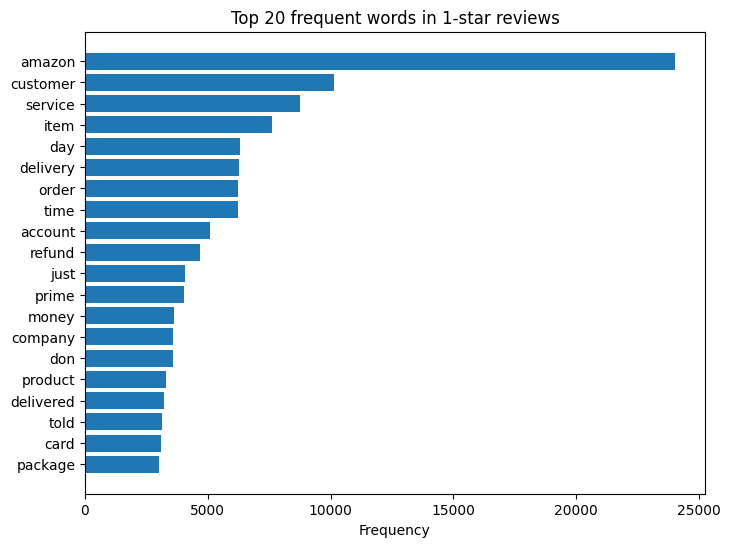

In [ ]:
# VISUALIZATION 3: Top 20 frequent terms (bar chart)
top_terms_df = top_terms_df.sort_values("freq", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_terms_df["term"], top_terms_df["freq"])
plt.title("Top 20 frequent words in 1-star reviews")
plt.xlabel("Frequency")
plt.ylabel("")
plt.show()


The bar graph indicates that concerns regarding orders, shipping, and customer service account for the majority of 1-star evaluations.  Refunds, accounts, and Prime are frequently mentioned, which suggests problems with billing and subscriptions.  Overall, the findings point to operational shortcomings and inadequate customer service as the primary causes of significant customer discontent rather than just poor product quality.

In [ ]:
#LDA topic modeling 
# Remove empty documents 
dtm_lda = dtm_1star_trim

# Create an LDA model with 6 topics
lda_model = LatentDirichletAllocation(
    n_components=6,          
    random_state=123         
)

# Fit the LDA model to the document-term matrix
lda_model.fit(dtm_lda)
print(lda_model)

LatentDirichletAllocation(n_components=6, random_state=123)


The document-term matrix created from one-star reviews was used to estimate a Latent Dirichlet Allocation (LDA) model using the Variational EM technique.  Six topics, each of which represented a hidden theme of customer unhappiness, were described for the model. This method makes it possible to identify recurrent complaint patterns, by classifying terms that commonly appear together in bad reviews.

In [ ]:
#Topic Terms per Topic
lda_terms = vectorizer_1star_trim.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_word_indices = topic.argsort()[::-1][:10]         
    top_words = lda_terms[top_word_indices]               
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: amazon, item, refund, return, customer, service, told, sent, received, said
Topic 2: customer, amazon, prime, service, time, order, phone, just, told, help
Topic 3: amazon, day, item, order, delivery, refund, ordered, time, shipping, seller
Topic 4: amazon, customer, service, review, company, product, don, just, like, time
Topic 5: account, amazon, card, gift, credit, money, email, bank, customer, order
Topic 6: delivery, amazon, package, delivered, driver, parcel, door, service, time, deliver


->Topic 1 – Delivery Delays & Returns

Key words: amazon, get, package, day, time, customer, item, refund, return
Interpretation:
Customers are frustrated about late or missing packages, long waiting times, and having to request refunds or returns due to delivery failures.


->Topic 2 – Order Processing & Account Issues

Key words: order, service, account, day, time, customer, amazon, still
Interpretation:
This topic reflects problems related to order processing, account verification, and delays in resolving issues, often involving repeated contact with customer service.


->Topic 3 – Delivery & Customer Experience Breakdown

Key words: amazon, order, customer, delivery, deliver, receive, account, call
Interpretation:
Customers report not receiving orders, failed deliveries, and the need to contact support multiple times without effective resolution.


->Topic 4 – Refunds, Prime & Service Promises

Key words: refund, deliver, prime, now, will, one
Interpretation:
This topic centers on refund-related complaints and unmet expectations from Amazon Prime, where promised benefits are not delivered on time.


->Topic 5 – Poor Customer Service Communication

Key words: service, customer, say, tell, call, even
Interpretation:
Customers express dissatisfaction with customer service interactions, including unclear responses, repeated explanations, and perceived lack of accountability.


->Topic 6 – Product & Subscription Frustrations

Key words: service, item, amazon, prime, even
Interpretation:
This topic highlights issues with specific products or items and dissatisfaction related to Prime subscriptions, often questioning value for money.


In [ ]:
# Comparison between 1-star and 4-5 star products using TF-IDF
df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
# Create DTM for both groups
vectorizer_all = CountVectorizer(min_df=0.01, token_pattern=r"\b[a-zA-Z]{3,}\b")
dtm_all_trim = vectorizer_all.fit_transform(df["clean_text"])
group_labels = df["group"].values

Compare TF-IDF

In [ ]:
# Convert DTM to matrix
dtm_mat = dtm_all_trim.toarray()

In [ ]:
# Compute Average Term Frequency by Group
tf_1star = dtm_mat[group_labels == "1-star"].mean(axis=0)
tf_high = dtm_mat[group_labels == "4-5 star"].mean(axis=0)


In [ ]:
# Difference Score
comparison = pd.DataFrame({
    "term": vectorizer_all.get_feature_names_out(),  
    "tf_1star": tf_1star,                             
    "tf_45star": tf_high                              
})
comparison["diff"] = comparison["tf_1star"] - comparison["tf_45star"]

In [ ]:
#Top words unique to 1-star reviews
top_1star_unique = comparison.sort_values("diff", ascending=False).head(20)
print(top_1star_unique)

          term  tf_1star  tf_45star      diff
14      amazon  1.831517   0.876632  0.954885
101   customer  0.772994   0.267010  0.505984
229       item  0.579822   0.203780  0.376042
5      account  0.387259   0.024742  0.362517
104        day  0.481597   0.141065  0.340532
301      order  0.475882   0.154983  0.320899
409    service  0.665778   0.354639  0.311138
364     refund  0.356702   0.060137  0.296565
115   delivery  0.477025   0.219416  0.257609
476       time  0.473215   0.225086  0.248129
278      money  0.275242   0.032990  0.242252
478       told  0.239275   0.010309  0.228965
57        card  0.236226   0.015979  0.220247
233       just  0.310676   0.095876  0.214800
130        don  0.272041   0.057904  0.214138
393       said  0.221443   0.018213  0.203230
113  delivered  0.243999   0.049828  0.194171
307    package  0.229444   0.042784  0.186661
138      email  0.199268   0.014605  0.184664
119        did  0.175112   0.030928  0.144185


In [ ]:
#Top words unique to 4-5 star reviews
top_45star_unique = comparison.sort_values("diff", ascending=True).head(20)
print(top_45star_unique)

          term  tf_1star  tf_45star      diff
191      great  0.035739   0.227663 -0.191924
262       love  0.014707   0.138144 -0.123437
188       good  0.116818   0.217869 -0.101052
34        best  0.023623   0.121134 -0.097511
162       fast  0.014936   0.103265 -0.088329
136       easy  0.013716   0.092096 -0.078380
335      price  0.077193   0.150515 -0.073323
146  excellent  0.004039   0.068213 -0.064174
417   shopping  0.040311   0.094158 -0.053847
469       text  0.022937   0.068213 -0.045276
13     amazing  0.006172   0.051375 -0.045202
351      quick  0.009068   0.046735 -0.037667
352    quickly  0.008382   0.040893 -0.032511
470      thank  0.013793   0.042096 -0.028304
297     online  0.056390   0.082131 -0.025741
369   reliable  0.008611   0.031271 -0.022661
306    overall  0.004801   0.025258 -0.020457
363  recommend  0.017069   0.037285 -0.020216
425       site  0.052503   0.072680 -0.020177
503    usually  0.014250   0.032131 -0.017881


The comparison reveals that while 4–5-star ratings highlight quick, simple, and dependable encounters, whereas 1-star reviews are dominated by terminology linked to unsolved issues, delivery delays, and poor communication.  This suggests that while seamless execution and efficient service are the main drivers of customer satisfaction, process failures are the main cause of customer dissatisfaction.


Recommendations: How Companies Can Reduce Customer Dissatisfaction?

According to the analysis, operational failures such delivery delays, unresolved account issues, and poor communication are the main causes of consumer unhappiness.  Positive client experiences, on the other hand, are defined by dependability, simplicity, and quickness.  Businesses can concentrate on enhancing delivery performance, boosting customer service responsiveness, and streamlining account and refund procedures in order to lower the number of 1-star ratings.  Organizations can provide more consistent and fulfilling client journeys by utilizing best practices from high rated experiences.